# Sales Forecasting Analysis

## Project Overview
This project analyzes historical sales data to understand sales patterns over time and build a forecasting workflow for future sales estimation. The analysis includes data cleaning, exploratory data analysis (EDA), time-based feature preparation, and sales forecasting.

## Objective
The goal is to identify trends, seasonality, and sales behavior over time, and to prepare a baseline forecasting analysis that can support business planning and decision-making.

## Dataset Description
The dataset contains sales-related information such as:
- order date
- product category
- region
- units sold
- unit price
- revenue
- discount
- customer segment

The main target of the analysis is **Revenue**, which will be used to study historical sales performance and support forecasting.

## Project Workflow
1. Data loading and inspection
2. Data cleaning
3. Exploratory data analysis
4. Datetime conversion and time-based feature creation
5. Aggregation of sales over time
6. Trend and seasonality analysis
7. Baseline sales forecasting
8. Forecast evaluation and interpretation
9. Business insights and recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("sales_forecasting_raw.csv")
df.head()

,date,store_id,product_category,region,units_sold,revenue,discount,marketing_spend,holiday
0,2024-01-01,S001,Electronics,North,66,11728.20,20.0,511.99,1
1,2024-01-01,S001,Home,North,50,5464.70,0.0,271.59,1
2,2024-01-01,S001,Fashion,North,56,2120.39,15.0,761.23,1
3,2024-01-01,S002,Electronics,South,54,16502.40,5.0,301.74,1
4,2024-01-01,S002,Home,South,41,2468.32,5.0,575.14,1


## Data Loading and Initial Inspection
In this step, the dataset is loaded and inspected to understand its structure, column types, missing values, and potential data quality issues before cleaning and analysis.

In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (2204, 9)

Columns:
['date', 'store_id', 'product_category', 'region', 'units_sold', 'revenue', 'discount', 'marketing_spend', 'holiday']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2204 entries, 0 to 2203
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              2204 non-null   object 
 1   store_id          2204 non-null   object 
 2   product_category  2204 non-null   object 
 3   region            2204 non-null   object 
 4   units_sold        2204 non-null   int64  
 5   revenue           2204 non-null   float64
 6   discount          2201 non-null   float64
 7   marketing_spend   2201 non-null   float64
 8   holiday           2204 non-null   int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 155.1+ KB
None

Missing values:
date                0
store_id            0
product_category    0
region              0
units_sold          0
revenue             0
discoun

## Data Cleaning
In this step, the dataset is cleaned by checking for duplicates, handling missing values, and preparing the data for further analysis.

In [3]:
# remove duplicate rows
df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())
print("New shape:", df.shape)

Duplicate rows after cleaning: 0
New shape: (2196, 9)


### Handling Missing Values
The dataset contains a small number of missing values in the `discount` and `marketing_spend` columns. These values will be inspected and then imputed using appropriate summary statistics.

In [4]:
print("discount median:", df["discount"].median())
print("marketing_spend median:", df["marketing_spend"].median())

discount median: 10.0
marketing_spend median: 634.66


Missing values in `discount` and `marketing_spend` are filled using the median value of each column. This keeps the dataset complete while minimizing the effect of potential outliers.

In [5]:
df["discount"] = df["discount"].fillna(df["discount"].median())
df["marketing_spend"] = df["marketing_spend"].fillna(df["marketing_spend"].median())

print(df.isnull().sum())

date                0
store_id            0
product_category    0
region              0
units_sold          0
revenue             0
discount            0
marketing_spend     0
holiday             0
dtype: int64


### Inspecting Categorical Columns
The categorical columns are inspected to identify inconsistent labels, formatting issues, or unexpected category values that may affect the analysis.

In [6]:
object_cols = df.select_dtypes(include="object").columns
object_cols

Index(['date', 'store_id', 'product_category', 'region'], dtype='object')

In [7]:
for col in object_cols:
    print(f"\n{col}:")
    print(df[col].unique())


date:
['2024-01-01' '2024-01-02' '2024-01-03' '2024-01-04' '2024-01-05'
 '2024-01-06' '2024-01-07' '2024-01-08' '2024-01-09' '2024-01-10'
 '2024-01-11' '2024-01-12' '2024-01-13' '2024-01-14' '2024-01-15'
 '2024-01-16' '2024-01-17' '2024-01-18' '2024-01-19' '2024-01-20'
 '2024-01-21' '2024-01-22' '2024-01-23' '2024-01-24' '2024-01-25'
 '2024-01-26' '2024-01-27' '2024-01-28' '2024-01-29' '2024-01-30'
 '2024-01-31' '2024-02-01' '2024-02-02' '2024-02-03' '2024-02-04'
 '2024-02-05' '2024-02-06' '2024-02-07' '2024-02-08' '2024-02-09'
 '2024-02-10' '2024-02-11' '2024-02-12' '2024-02-13' '2024-02-14'
 '2024-02-15' '2024-02-16' '2024-02-17' '2024-02-18' '2024-02-19'
 '2024-02-20' '2024-02-21' '2024-02-22' '2024-02-23' '2024-02-24'
 '2024-02-25' '2024-02-26' '2024-02-27' '2024-02-28' '2024-02-29'
 '2024-03-01' '2024-03-02' '2024-03-03' '2024-03-04' '2024-03-05'
 '2024-03-06' '2024-03-07' '2024-03-08' '2024-03-09' '2024-03-10'
 '2024-03-11' '2024-03-12' '2024-03-13' '2024-03-14' '2024-03-15'
 '2

### Standardizing Categorical Values
Some categorical values are stored with inconsistent capitalization. These values are standardized to ensure consistency in the analysis.

In [8]:
df["product_category"] = df["product_category"].replace({
    "fashion": "Fashion"
})

df["region"] = df["region"].replace({
    "south": "South"
})

In [9]:
print("product_category:")
print(df["product_category"].unique())

print("\nregion:")
print(df["region"].unique())

product_category:
['Electronics' 'Home' 'Fashion']

region:
['North' 'South']


### Checking Numerical Ranges
Numerical columns are checked to detect invalid or unrealistic values before continuing with the time-based analysis.

In [10]:
print("units_sold min/max:", df["units_sold"].min(), df["units_sold"].max())
print("revenue min/max:", df["revenue"].min(), df["revenue"].max())
print("discount min/max:", df["discount"].min(), df["discount"].max())
print("marketing_spend min/max:", df["marketing_spend"].min(), df["marketing_spend"].max())

units_sold min/max: 21 84
revenue min/max: -50.0 31505.18
discount min/max: 0.0 20.0
marketing_spend min/max: 100.01 1199.51


### Handling Invalid Revenue Values
Negative revenue values are treated as invalid entries. These values are replaced with missing values and then imputed using the median revenue.

In [11]:
df.loc[df["revenue"] < 0, "revenue"] = np.nan

print("Missing revenue values after correction:", df["revenue"].isnull().sum())
print("Revenue median:", df["revenue"].median())

Missing revenue values after correction: 2
Revenue median: 3851.12


The invalid revenue values are imputed using the median revenue value to keep the dataset complete while reducing sensitivity to extreme observations.

In [12]:
df["revenue"] = df["revenue"].fillna(df["revenue"].median())

print(df.isnull().sum())

date                0
store_id            0
product_category    0
region              0
units_sold          0
revenue             0
discount            0
marketing_spend     0
holiday             0
dtype: int64


### Converting the Date Column
The `date` column is converted to datetime format so that the dataset can be analyzed over time and used for time-based feature engineering.

In [13]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dtype)

datetime64[ns]


In [14]:
print("Earliest date:", df["date"].min())
print("Latest date:", df["date"].max())

Earliest date: 2024-01-01 00:00:00
Latest date: 2024-12-31 00:00:00


### Time-Based Feature Engineering
Additional time-based features are created from the `date` column to support trend analysis, seasonality exploration, and forecasting.

In [15]:
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek
df["quarter"] = df["date"].dt.quarter
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

df.head()

,date,store_id,product_category,region,units_sold,revenue,discount,marketing_spend,holiday,month,day_of_week,quarter,is_weekend
0,2024-01-01,S001,Electronics,North,66,11728.20,20.0,511.99,1,1,0,1,0
1,2024-01-01,S001,Home,North,50,5464.70,0.0,271.59,1,1,0,1,0
2,2024-01-01,S001,Fashion,North,56,2120.39,15.0,761.23,1,1,0,1,0
3,2024-01-01,S002,Electronics,South,54,16502.40,5.0,301.74,1,1,0,1,0
4,2024-01-01,S002,Home,South,41,2468.32,5.0,575.14,1,1,0,1,0


## Exploratory Data Analysis (EDA)

### Daily Revenue Trend
In this step, revenue is aggregated by date to observe how total sales change over time and whether visible patterns or fluctuations appear across the year.

In [16]:
daily_revenue = df.groupby("date")["revenue"].sum()
daily_revenue.head()

,revenue
date,
2024-01-01,42878.31
2024-01-02,36048.82
2024-01-03,38800.62
2024-01-04,45152.33
2024-01-05,45711.78


In [38]:
import os
os.makedirs("images", exist_ok=True)

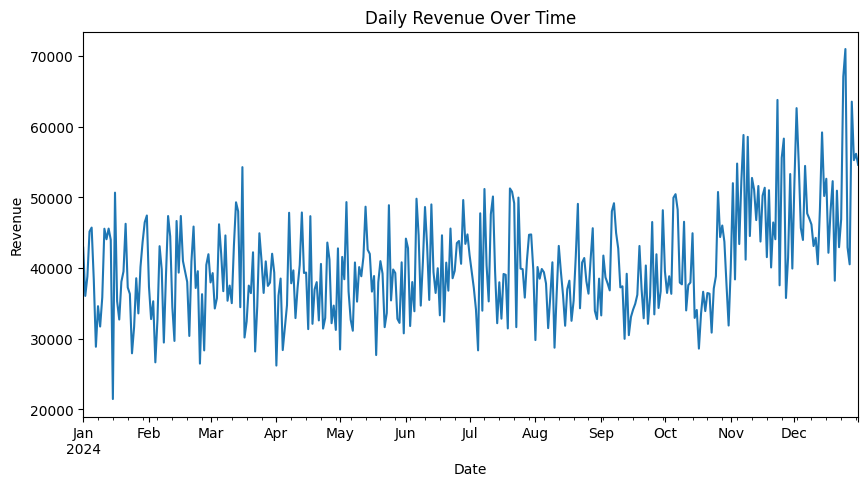

In [40]:
plt.figure(figsize=(10, 5))
daily_revenue.plot()
plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.savefig("images/daily_revenue_over_time.png", bbox_inches="tight")
plt.show()

The daily revenue trend shows noticeable fluctuations throughout the year, indicating that sales vary considerably from day to day.

For most of the year, revenue remains in a relatively stable range, but there is a visible increase toward the end of the year, especially in November and December. This suggests a possible seasonal effect, where sales become stronger during the final months.

Overall, the time series appears volatile, but with an upward pattern near year-end that may be important for forecasting.

### Monthly Revenue Trend
To better understand broader sales patterns, revenue is aggregated by month. This helps identify seasonal changes and whether some months perform better than others.

In [18]:
monthly_revenue = df.groupby("month")["revenue"].sum()
monthly_revenue

,revenue
month,
1,1204090.25
2,1091327.12
3,1215491.72
4,1106726.25
5,1174608.44
6,1229895.07
7,1257918.40
8,1166070.00
9,1148463.08


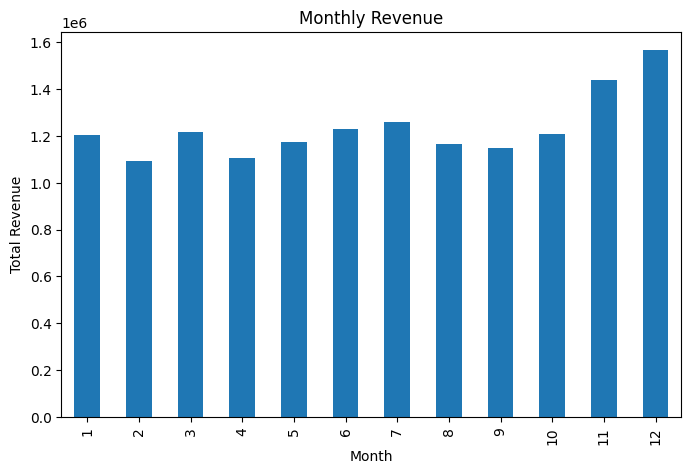

In [41]:
plt.figure(figsize=(8, 5))
monthly_revenue.plot(kind="bar")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.savefig("images/monthly_revenue.png", bbox_inches="tight")
plt.show()

The monthly revenue chart shows that sales remain relatively stable for most of the year, with moderate variation between months.

However, revenue increases noticeably in November and reaches its highest level in December. This suggests a strong year-end seasonal effect, likely driven by increased customer demand, promotions, or holiday shopping behavior.

Overall, the monthly pattern indicates that the final quarter, especially the last two months, plays an important role in total annual sales performance.

### Revenue by Product Category
This analysis compares total revenue across product categories to identify which categories contribute most to overall sales.

In [20]:
category_revenue = df.groupby("product_category")["revenue"].sum()
category_revenue

,revenue
product_category,
Electronics,10263275.56
Fashion,2234771.80
Home,2311937.38


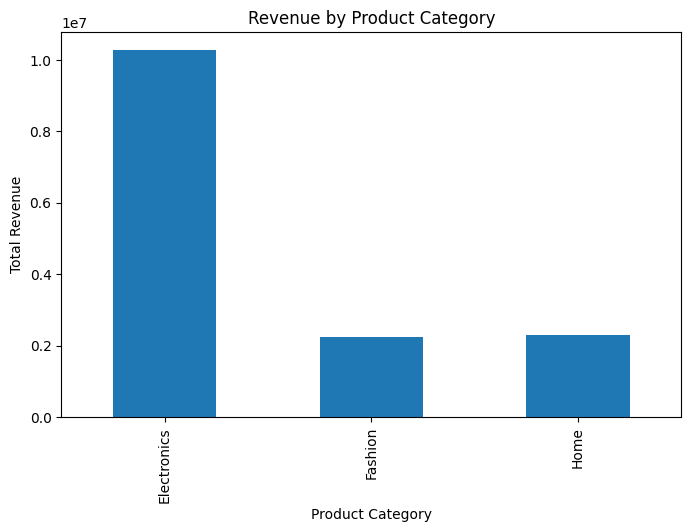

In [42]:
plt.figure(figsize=(8, 5))
category_revenue.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.savefig("images/revenue_by_product_category.png", bbox_inches="tight")
plt.show()

The revenue by product category chart shows that Electronics generates by far the highest total revenue compared to Home and Fashion.

This suggests that Electronics is the strongest-performing category and likely plays the most important role in overall business results. Home and Fashion contribute much less and appear relatively similar in total revenue.

From a business perspective, this may indicate that Electronics has either higher sales volume, higher prices, or both.

### Revenue on Holiday vs Non-Holiday Days
This analysis compares the average revenue generated on holiday and non-holiday days to see whether holidays are associated with stronger sales performance.

In [22]:
holiday_revenue = df.groupby("holiday")["revenue"].mean()
holiday_revenue

,revenue
holiday,
0,6701.187907
1,9317.190556


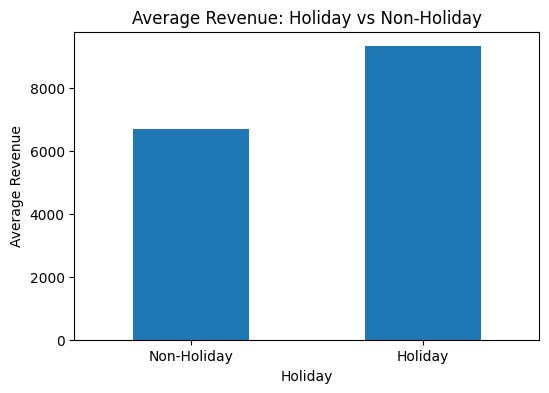

In [43]:
plt.figure(figsize=(6, 4))
holiday_revenue.plot(kind="bar")
plt.title("Average Revenue: Holiday vs Non-Holiday")
plt.xlabel("Holiday")
plt.ylabel("Average Revenue")
plt.xticks([0, 1], ["Non-Holiday", "Holiday"], rotation=0)
plt.savefig("images/holiday_vs_nonholiday_revenue.png", bbox_inches="tight")
plt.show()

The holiday vs non-holiday revenue chart shows that average revenue is noticeably higher on holiday days than on non-holiday days.

This suggests that holidays are associated with stronger sales performance, likely because customers buy more during special shopping periods. From a business perspective, this means holiday periods are especially important for sales planning, promotions, stock preparation, and marketing strategy.

### Revenue by Region
This analysis compares total revenue across regions to identify which market contributes the most to overall sales.

In [24]:
region_revenue = df.groupby("region")["revenue"].sum().sort_values()
region_revenue

,revenue
region,
South,7400959.79
North,7409024.95


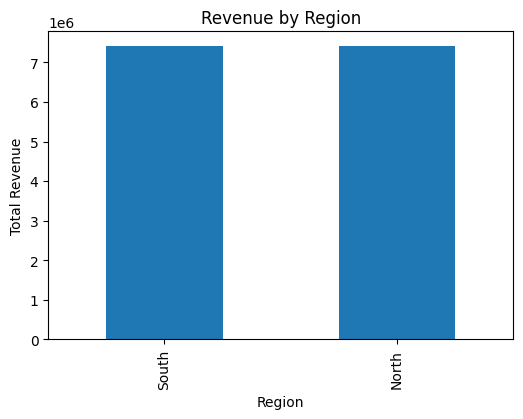

In [44]:
plt.figure(figsize=(6, 4))
region_revenue.plot(kind="bar")
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.savefig("images/revenue_by_region.png", bbox_inches="tight")
plt.show()

The revenue by region chart shows that North and South generated almost the same total revenue.

This suggests that sales performance was balanced across the two regions, with no major gap in overall contribution. From a business perspective, this can indicate that both markets are equally important and should be supported with similar attention in sales strategy, inventory planning, and promotional efforts.

### Revenue by Discount Level
This analysis examines how average revenue changes across different discount levels.

In [26]:
discount_revenue = df.groupby("discount")["revenue"].mean().sort_index()
discount_revenue

,revenue
discount,
0.0,6661.342849
5.0,7177.160023
10.0,6718.706614
15.0,6616.889857
20.0,6389.731461


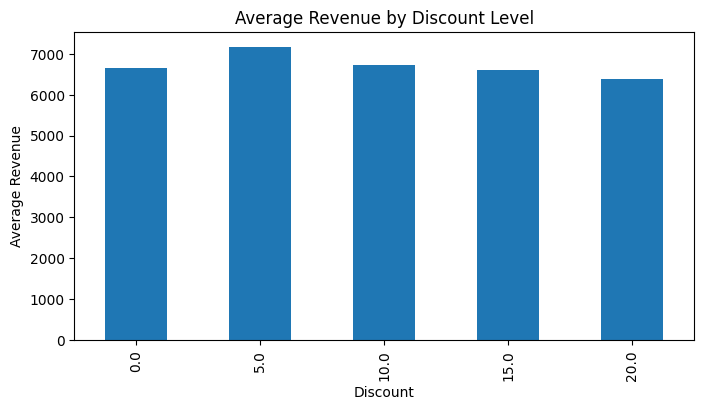

In [45]:
plt.figure(figsize=(8, 4))
discount_revenue.plot(kind="bar")
plt.title("Average Revenue by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Revenue")
plt.savefig("images/average_revenue_by_discount_level.png", bbox_inches="tight")
plt.show()

The average revenue by discount level chart shows that the 5% discount generated the highest average revenue, while higher discount levels such as 15% and 20% did not lead to better results.

This suggests that a small discount may be effective in encouraging purchases, but offering larger discounts does not necessarily improve revenue. From a business perspective, moderate discounts may be more efficient because they can support sales while protecting profit margins.

### Revenue by Product Category and Holiday
This analysis compares average revenue across product categories during holiday and non-holiday periods.

In [28]:
category_holiday_revenue = df.groupby(["product_category", "holiday"])["revenue"].mean().unstack()
category_holiday_revenue

holiday,0,1
product_category,,
Electronics,13934.221514,19219.672500
Fashion,3028.421856,4020.935000
Home,3141.233719,4710.964167


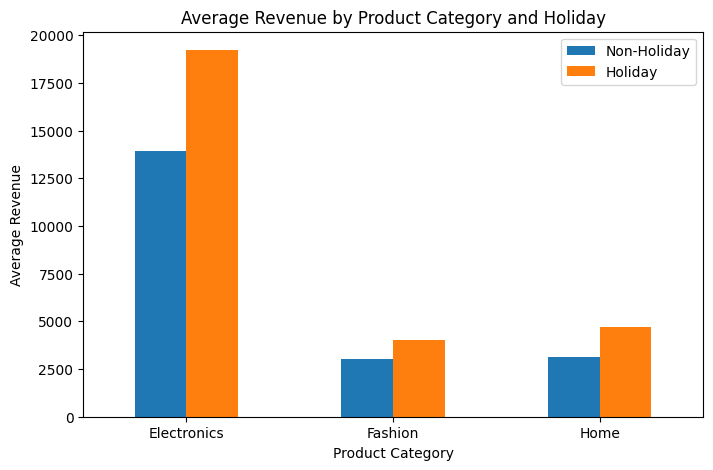

In [46]:
category_holiday_revenue.plot(kind="bar", figsize=(8, 5))
plt.title("Average Revenue by Product Category and Holiday")
plt.xlabel("Product Category")
plt.ylabel("Average Revenue")
plt.xticks(rotation=0)
plt.legend(["Non-Holiday", "Holiday"])
plt.savefig("images/revenue_by_category_and_holiday.png", bbox_inches="tight")
plt.show()

The chart shows that average revenue is higher during holidays for all product categories. Electronics generates the highest revenue in both holiday and non-holiday periods, with a particularly strong increase during holidays.

This suggests that holiday periods have a positive impact on sales overall, especially for Electronics. From a business perspective, this means that promotional campaigns, stock planning, and marketing efforts should be strengthened before holidays, particularly for high-performing categories such as Electronics.

## Time Series Preparation
In this section, we prepare the dataset for sales forecasting by aggregating revenue over time and creating a daily time series.

In [30]:
daily_sales = df.groupby("date")["revenue"].sum().reset_index()
daily_sales.head()

,date,revenue
0,2024-01-01,42878.31
1,2024-01-02,36048.82
2,2024-01-03,38800.62
3,2024-01-04,45152.33
4,2024-01-05,45711.78


In [31]:
daily_sales = daily_sales.sort_values("date")
daily_sales.set_index("date", inplace=True)
daily_sales.head()

,revenue
date,
2024-01-01,42878.31
2024-01-02,36048.82
2024-01-03,38800.62
2024-01-04,45152.33
2024-01-05,45711.78


(366, 1)


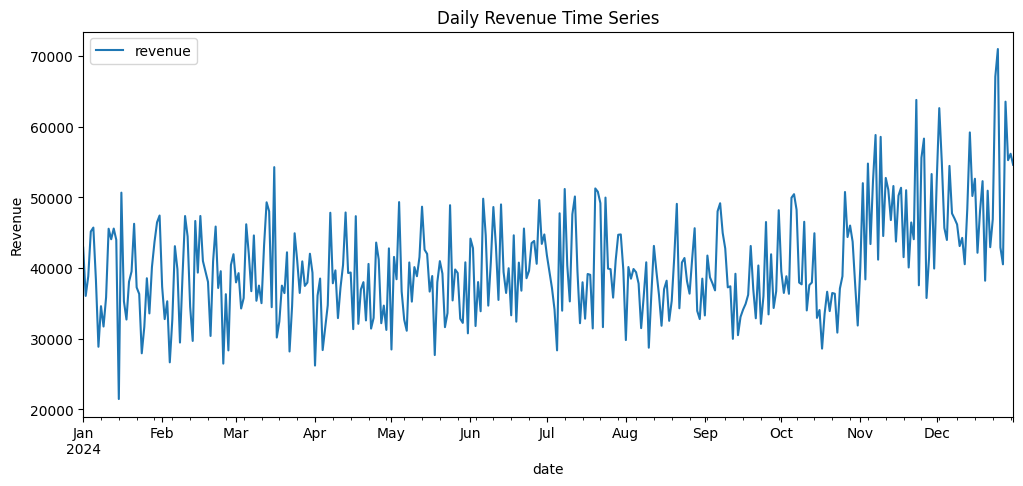

In [32]:
print(daily_sales.shape)
daily_sales.plot(figsize=(12,5), title="Daily Revenue Time Series")
plt.ylabel("Revenue")
plt.show()

## Train-Test Split
To evaluate the forecasting model properly, the daily time series is split into a training set and a test set.  
The model will be trained on earlier dates and tested on the most recent period to measure how well it predicts unseen future values.

In [33]:
train = daily_sales.iloc[:-30]
test = daily_sales.iloc[-30:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (336, 1)
Test shape: (30, 1)


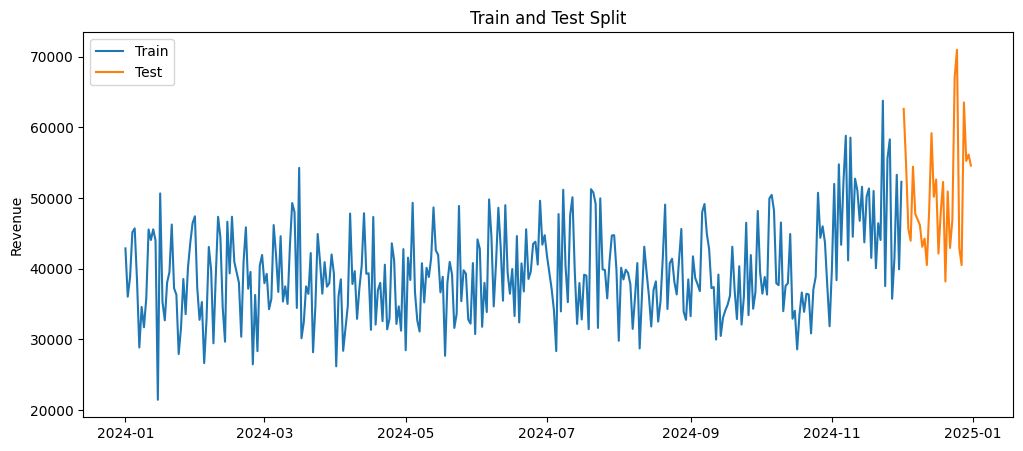

In [34]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train["revenue"], label="Train")
plt.plot(test.index, test["revenue"], label="Test")
plt.title("Train and Test Split")
plt.ylabel("Revenue")
plt.legend()
plt.show()

## Forecasting with Moving Average
As a simple baseline forecasting approach, a moving average is used.  
This method estimates future revenue based on the average revenue from the most recent days in the training period.

In [35]:
moving_avg_value = train["revenue"].tail(7).mean()
forecast = [moving_avg_value] * len(test)

print("7-day moving average forecast value:", moving_avg_value)

7-day moving average forecast value: 48089.21857142857


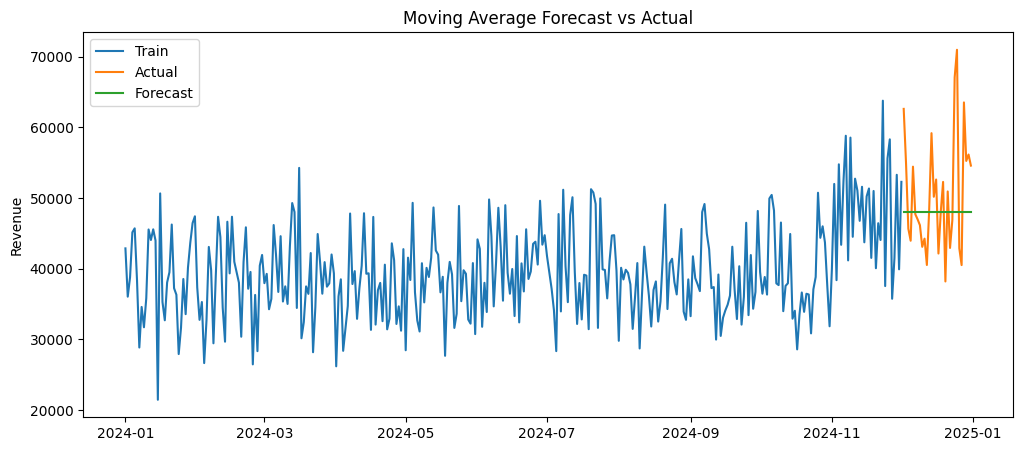

In [47]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train["revenue"], label="Train")
plt.plot(test.index, test["revenue"], label="Actual")
plt.plot(test.index, forecast, label="Forecast")
plt.title("Moving Average Forecast vs Actual")
plt.ylabel("Revenue")
plt.legend()
plt.savefig("images/moving_average_forecast_vs_actual.png", bbox_inches="tight")
plt.show()

## Model Evaluation
To evaluate forecasting performance, error metrics are calculated by comparing predicted revenue values with the actual revenue in the test set.  
The main metrics used are Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test["revenue"], forecast)
rmse = np.sqrt(mean_squared_error(test["revenue"], forecast))

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))

MAE: 6435.45
RMSE: 8408.73


## Conclusion
This project analyzed retail sales data and applied a simple moving average model to forecast daily revenue.  
The analysis showed that revenue increased toward the end of the year, holiday periods were associated with higher sales, and Electronics generated the highest revenue among product categories.  
The forecasting model provided a useful baseline, but the evaluation metrics indicate that more advanced time series methods could improve prediction accuracy.